##Importing all Libraries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

##Loading Dataset

In [ ]:
df = pd.read_csv('/content/Advertising.csv')
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


##Basic Data Exploration

In [ ]:
print(df.info())
print('\n')
print(df.describe())
print('\n')
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.4

##Data Cleaning

In [ ]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


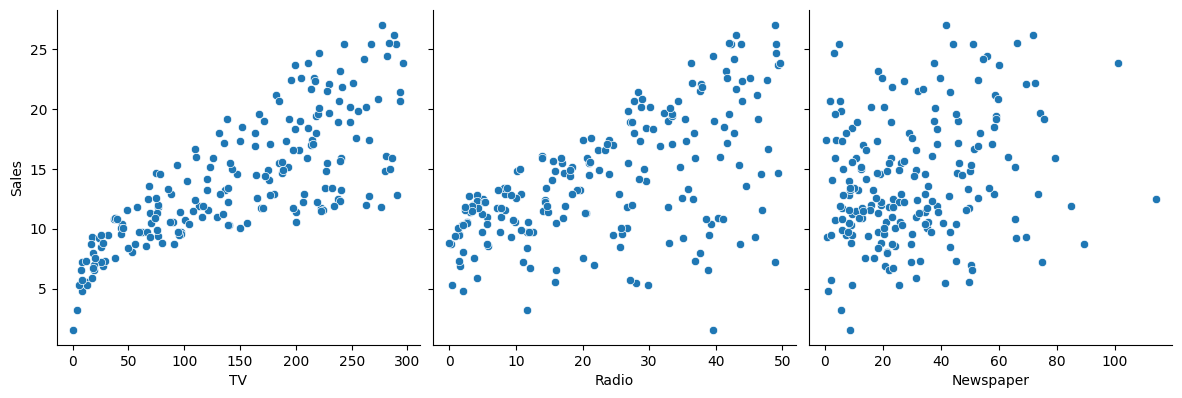

In [ ]:
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')

In [ ]:
num_duplicates = df.duplicated().sum()
if num_duplicates == 0:
    print("No duplicate rows found.")
else:
    print(f"Found {num_duplicates} duplicate row(s).")
    # Optionally, you could display them:
    # print(df[df.duplicated(keep=False)])

No duplicate rows found.


##Exploratory Data Analysis (EDA)

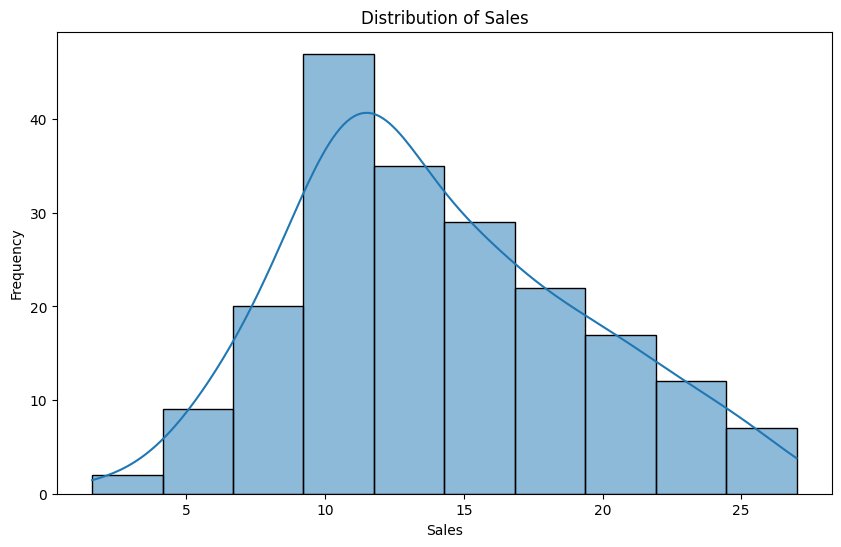

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sales'], kde=True, bins=10)
plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

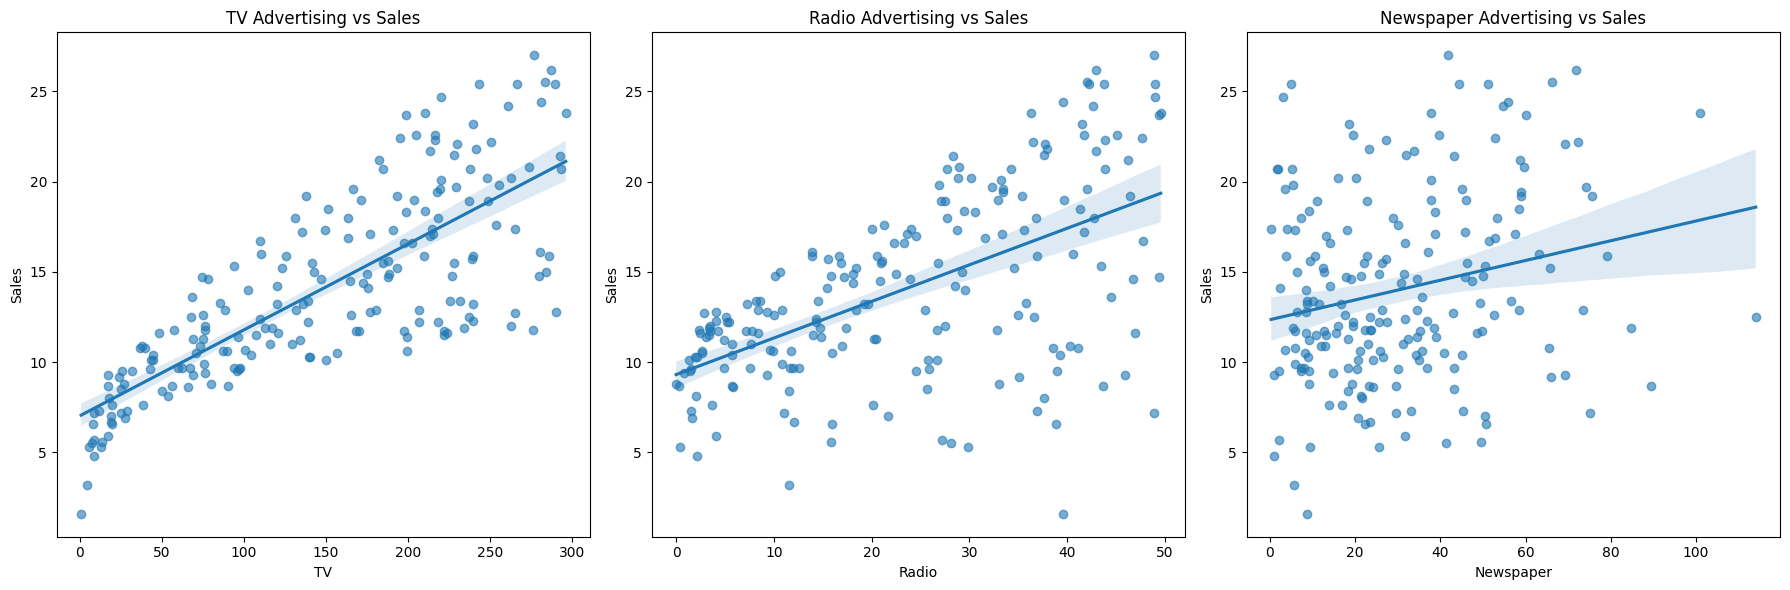

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.regplot(x='TV', y='Sales', data=df, ax=axes[0], scatter_kws={'alpha':0.6})
axes[0].set_title('TV Advertising vs Sales')
sns.regplot(x='Radio', y='Sales', data=df, ax=axes[1], scatter_kws={'alpha':0.6})
axes[1].set_title('Radio Advertising vs Sales')
sns.regplot(x='Newspaper', y='Sales', data=df, ax=axes[2], scatter_kws={'alpha':0.6})
axes[2].set_title('Newspaper Advertising vs Sales')
plt.tight_layout()
plt.show()

##Correlation Analysis

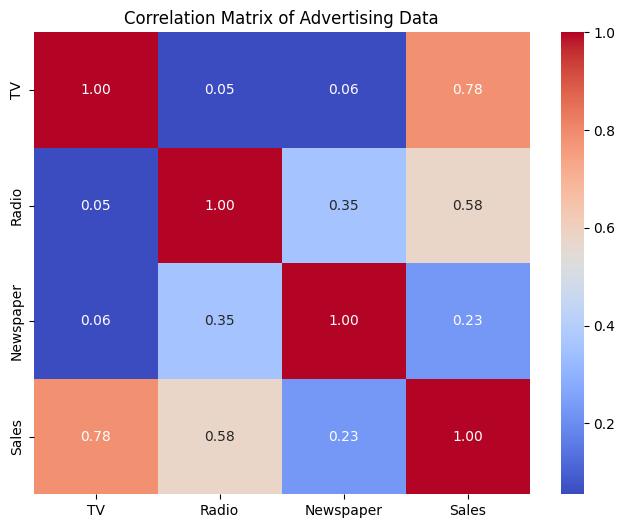

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Advertising Data')
plt.show()

##Advertising vs Sales Analysis

/tmp/ipykernel_15943/4258567768.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tv_impact = df.groupby('TV_Spending_Category')['Sales'].mean().reset_index()
/tmp/ipykernel_15943/4258567768.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TV_Spending_Category', y='Sales', data=tv_impact, palette='viridis')


Average Sales based on TV Advertising Spending Categories:
  TV_Spending_Category   Sales
0                  Low   8.390
1           Medium-Low  12.686
2          Medium-High  16.548
3                 High  18.466


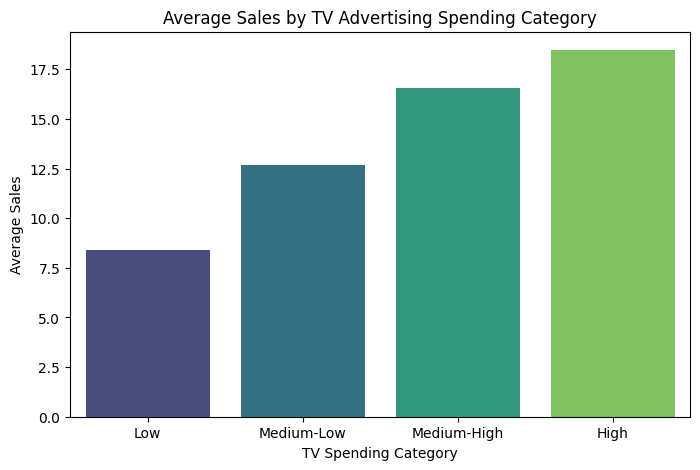

In [ ]:
df['TV_Spending_Category'] = pd.qcut(df['TV'], q=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
tv_impact = df.groupby('TV_Spending_Category')['Sales'].mean().reset_index()
print('Average Sales based on TV Advertising Spending Categories:')
print(tv_impact)

plt.figure(figsize=(8, 5))
sns.barplot(x='TV_Spending_Category', y='Sales', data=tv_impact, palette='viridis')
plt.title('Average Sales by TV Advertising Spending Category')
plt.xlabel('TV Spending Category')
plt.ylabel('Average Sales')
plt.show()

##Feature Engineering

In [ ]:
df['TV_Radio_Interaction'] = df['TV'] * df['Radio']
df['Total_Spend'] = df['TV'] + df['Radio'] + df['Newspaper']
print("DataFrame with new engineered features:")
print(df.head())

DataFrame with new engineered features:
      TV  Radio  Newspaper  Sales TV_Spending_Category  TV_Radio_Interaction  \
0  230.1   37.8       69.2   22.1                 High               8697.78   
1   44.5   39.3       45.1   10.4                  Low               1748.85   
2   17.2   45.9       69.3    9.3                  Low                789.48   
3  151.5   41.3       58.5   18.5          Medium-High               6256.95   
4  180.8   10.8       58.4   12.9          Medium-High               1952.64   

   Total_Spend  
0        337.1  
1        128.9  
2        132.4  
3        251.3  
4        250.0  


##Handle Categorical Features

In [ ]:
df = pd.get_dummies(df, columns=['TV_Spending_Category'], drop_first=True)
print("DataFrame after one-hot encoding 'TV_Spending_Category':")
print(df.head())

DataFrame after one-hot encoding 'TV_Spending_Category':
      TV  Radio  Newspaper  Sales  TV_Radio_Interaction  Total_Spend  \
0  230.1   37.8       69.2   22.1               8697.78        337.1   
1   44.5   39.3       45.1   10.4               1748.85        128.9   
2   17.2   45.9       69.3    9.3                789.48        132.4   
3  151.5   41.3       58.5   18.5               6256.95        251.3   
4  180.8   10.8       58.4   12.9               1952.64        250.0   

   TV_Spending_Category_Medium-Low  TV_Spending_Category_Medium-High  \
0                            False                             False   
1                            False                             False   
2                            False                             False   
3                            False                              True   
4                            False                              True   

   TV_Spending_Category_High  
0                       True  
1              

##Define Features and Target

In [ ]:
X = df.drop('Sales', axis=1)
y = df['Sales']

print("Shape of features (X):", X.shape)
print("Shape of target (y):", y.shape)
print("Features (X) head:")
print(X.head())
print("Target (y) head:")
print(y.head())

Shape of features (X): (200, 8)
Shape of target (y): (200,)
Features (X) head:
      TV  Radio  Newspaper  TV_Radio_Interaction  Total_Spend  \
0  230.1   37.8       69.2               8697.78        337.1   
1   44.5   39.3       45.1               1748.85        128.9   
2   17.2   45.9       69.3                789.48        132.4   
3  151.5   41.3       58.5               6256.95        251.3   
4  180.8   10.8       58.4               1952.64        250.0   

   TV_Spending_Category_Medium-Low  TV_Spending_Category_Medium-High  \
0                            False                             False   
1                            False                             False   
2                            False                             False   
3                            False                              True   
4                            False                              True   

   TV_Spending_Category_High  
0                       True  
1                      False  
2   

##Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (160, 8)
Shape of X_test: (40, 8)
Shape of y_train: (160,)
Shape of y_test: (40,)


##Feature Scaling

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled X_train head:")
print(pd.DataFrame(X_train_scaled, columns=X_train.columns).head())
print("\nScaled X_test head:")
print(pd.DataFrame(X_test_scaled, columns=X_test.columns).head())

Scaled X_train head:
         TV     Radio  Newspaper  TV_Radio_Interaction  Total_Spend  \
0 -0.404248 -1.028237  -0.337675             -0.786925    -0.621066   
1  0.320608 -0.919828  -1.161439             -0.559530    -0.112383   
2 -1.270511  0.259124   0.254251             -0.709132    -1.085420   
3 -1.042359 -0.696233  -0.574446             -0.819610    -1.215085   
4  0.879103 -1.387343  -0.707629             -0.894325     0.433981   

   TV_Spending_Category_Medium-Low  TV_Spending_Category_Medium-High  \
0                         1.623688                         -0.586973   
1                        -0.615882                          1.703655   
2                        -0.615882                         -0.586973   
3                        -0.615882                         -0.586973   
4                        -0.615882                         -0.586973   

   TV_Spending_Category_High  
0                  -0.577350  
1                  -0.577350  
2                  -0.5773

##Training Regression Model

In [ ]:
# Initialize the Linear Regression model
model = LinearRegression()

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


##Training Random Forest & Gradient Boosting

In [ ]:
# Initialize and train RandomForestRegressor
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)
print("Random Forest Regressor model trained successfully!")

# Initialize and train GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train_scaled, y_train)
print("Gradient Boosting Regressor model trained successfully!")

Random Forest Regressor model trained successfully!
Gradient Boosting Regressor model trained successfully!


##Training XGBoost & LightGBM

In [ ]:
# Initialize and train XGBoost Regressor
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train_scaled, y_train)
print("XGBoost Regressor model trained successfully!")

# Initialize and train LightGBM Regressor
lgbm_model = LGBMRegressor(random_state=42)
lgbm_model.fit(X_train_scaled, y_train)
print("LightGBM Regressor model trained successfully!")

XGBoost Regressor model trained successfully!
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001041 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 278
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 8
[LightGBM] [Info] Start training from score 14.100000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

##Hyperparameter Tuning

In [ ]:
# Define the parameter grid for RandomForestRegressor
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize GridSearchCV with RandomForestRegressor
grid_search = GridSearchCV(estimator=RandomForestRegressor(random_state=42),
                           param_grid=param_grid,
                           cv=3,
                           n_jobs=-1,
                           verbose=2,
                           scoring='neg_mean_squared_error')

# Fit GridSearchCV to the training data
grid_search.fit(X_train_scaled, y_train)

# Print the best parameters and best score
print("Best parameters for Random Forest Regressor:", grid_search.best_params_)
print("Best cross-validation score (negative MSE):", grid_search.best_score_)

# Store the best estimator
best_rf_model = grid_search.best_estimator_

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best parameters for Random Forest Regressor: {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best cross-validation score (negative MSE): -0.48078062247371617


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
324 fits failed out of a total of 972.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/util

In [ ]:
# Hyperparameter tuning for Gradient Boosting Regressor
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_grid_search = GridSearchCV(estimator=GradientBoostingRegressor(random_state=42),
                              param_grid=param_grid_gb,
                              cv=3,
                              n_jobs=-1,
                              verbose=2,
                              scoring='neg_mean_squared_error')

gb_grid_search.fit(X_train_scaled, y_train)

print("Best parameters for Gradient Boosting Regressor:", gb_grid_search.best_params_)
print("Best cross-validation score (negative MSE):", gb_grid_search.best_score_)

best_gb_model = gb_grid_search.best_estimator_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits
Best parameters for Gradient Boosting Regressor: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}
Best cross-validation score (negative MSE): -0.2874746064568025


In [ ]:
# Hyperparameter tuning for XGBoost Regressor
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

xgb_grid_search = GridSearchCV(estimator=XGBRegressor(random_state=42, use_label_encoder=False, eval_metric='rmse'),
                               param_grid=param_grid_xgb,
                               cv=3,
                               n_jobs=-1,
                               verbose=2,
                               scoring='neg_mean_squared_error')

xgb_grid_search.fit(X_train_scaled, y_train)

print("Best parameters for XGBoost Regressor:", xgb_grid_search.best_params_)
print("Best cross-validation score (negative MSE):", xgb_grid_search.best_score_)

best_xgb_model = xgb_grid_search.best_estimator_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [12:21:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost Regressor: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.6}
Best cross-validation score (negative MSE): -0.2747279935161157


In [ ]:
# Hyperparameter tuning for LightGBM Regressor
param_grid_lgbm = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, -1],  # -1 means no limit
    'num_leaves': [20, 31, 40],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

lgbm_grid_search = GridSearchCV(estimator=LGBMRegressor(random_state=42, verbose=-1),
                               param_grid=param_grid_lgbm,
                               cv=3,
                               n_jobs=-1,
                               verbose=2,
                               scoring='neg_mean_squared_error')

lgbm_grid_search.fit(X_train_scaled, y_train)

print("Best parameters for LightGBM Regressor:", lgbm_grid_search.best_params_)
print("Best cross-validation score (negative MSE):", lgbm_grid_search.best_score_)

best_lgbm_model = lgbm_grid_search.best_estimator_

Fitting 3 folds for each of 1296 candidates, totalling 3888 fits
Best parameters for LightGBM Regressor: {'colsample_bytree': 0.6, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'num_leaves': 20, 'subsample': 0.6}
Best cross-validation score (negative MSE): -1.2154607138474454


##Making Predictions

In [ ]:
# Make predictions using the best Random Forest model
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

# Make predictions using the best Gradient Boosting model
y_pred_gb_tuned = best_gb_model.predict(X_test_scaled)

# Make predictions using the best XGBoost model
y_pred_xgb_tuned = best_xgb_model.predict(X_test_scaled)

# Make predictions using the best LightGBM model
y_pred_lgbm_tuned = best_lgbm_model.predict(X_test_scaled)

print("Predictions have been generated for all hyperparameter-tuned models:")
print("  - y_pred_rf_tuned (Random Forest Regressor)")
print("  - y_pred_gb_tuned (Gradient Boosting Regressor)")
print("  - y_pred_xgb_tuned (XGBoost Regressor)")
print("  - y_pred_lgbm_tuned (LightGBM Regressor)")

Predictions have been generated for all hyperparameter-tuned models:
  - y_pred_rf_tuned (Random Forest Regressor)
  - y_pred_gb_tuned (Gradient Boosting Regressor)
  - y_pred_xgb_tuned (XGBoost Regressor)
  - y_pred_lgbm_tuned (LightGBM Regressor)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


##Evaluate Model

In [ ]:
print("Evaluate Models")

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} Evaluation ---")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")
    print("\n")

# Evaluate Linear Regression (original, not tuned)
# First, make predictions for the original Linear Regression model if not already done
# Assuming 'model' is the original Linear Regression model instance
y_pred_lr = model.predict(X_test_scaled)
evaluate_model(y_test, y_pred_lr, "Linear Regression (Original)")

# Evaluate tuned Random Forest
evaluate_model(y_test, y_pred_rf_tuned, "Random Forest Regressor (Tuned)")

# Evaluate tuned Gradient Boosting
evaluate_model(y_test, y_pred_gb_tuned, "Gradient Boosting Regressor (Tuned)")

# Evaluate tuned XGBoost
evaluate_model(y_test, y_pred_xgb_tuned, "XGBoost Regressor (Tuned)")

# Evaluate tuned LightGBM
evaluate_model(y_test, y_pred_lgbm_tuned, "LightGBM Regressor (Tuned)")

Evaluate Models
--- Linear Regression (Original) Evaluation ---
Mean Absolute Error (MAE): 0.5894
Mean Squared Error (MSE): 0.5952
Root Mean Squared Error (RMSE): 0.7715
R-squared (R2): 0.9811


--- Random Forest Regressor (Tuned) Evaluation ---
Mean Absolute Error (MAE): 0.6527
Mean Squared Error (MSE): 0.6436
Root Mean Squared Error (RMSE): 0.8022
R-squared (R2): 0.9796


--- Gradient Boosting Regressor (Tuned) Evaluation ---
Mean Absolute Error (MAE): 0.4837
Mean Squared Error (MSE): 0.4319
Root Mean Squared Error (RMSE): 0.6572
R-squared (R2): 0.9863


--- XGBoost Regressor (Tuned) Evaluation ---
Mean Absolute Error (MAE): 0.5401
Mean Squared Error (MSE): 0.4747
Root Mean Squared Error (RMSE): 0.6890
R-squared (R2): 0.9850


--- LightGBM Regressor (Tuned) Evaluation ---
Mean Absolute Error (MAE): 0.6209
Mean Squared Error (MSE): 0.6174
Root Mean Squared Error (RMSE): 0.7858
R-squared (R2): 0.9804




## Model Evaluation Summary

Based on the evaluation metrics, let's compare the performance of each model:

| Model                          | MAE      | MSE      | RMSE     | R-squared |
|:-------------------------------|:---------|:---------|:---------|:----------|
| Linear Regression (Original)   | 0.5894   | 0.5952   | 0.7715   | 0.9811    |
| Random Forest Regressor (Tuned)| 0.6527   | 0.6436   | 0.8022   | 0.9796    |
| Gradient Boosting Regressor (Tuned)| **0.4837** | **0.4319** | **0.6572** | **0.9863**|
| XGBoost Regressor (Tuned)      | 0.5401   | 0.4747   | 0.6890   | 0.9850    |
| LightGBM Regressor (Tuned)     | 0.6209   | 0.6174   | 0.7858   | 0.9804    |

**Key Observations:**

*   The **Gradient Boosting Regressor (Tuned)** consistently shows the best performance across all metrics, with the lowest MAE, MSE, and RMSE, and the highest R-squared value.
*   XGBoost Regressor (Tuned) also performed very well, coming in second.
*   Linear Regression (Original) and LightGBM Regressor (Tuned) performed similarly, with decent R-squared values but slightly higher error metrics compared to Gradient Boosting and XGBoost.
*   The Tuned Random Forest Regressor, while good, had slightly higher error metrics compared to the other models, especially the boosting models.

##Feature Importance Analysis

Feature Importances from Tuned Gradient Boosting Regressor:
                            Feature  Importance
3              TV_Radio_Interaction    0.878106
4                       Total_Spend    0.077940
0                                TV    0.041845
1                             Radio    0.001268
2                         Newspaper    0.000831
6  TV_Spending_Category_Medium-High    0.000009
5   TV_Spending_Category_Medium-Low    0.000000
7         TV_Spending_Category_High    0.000000


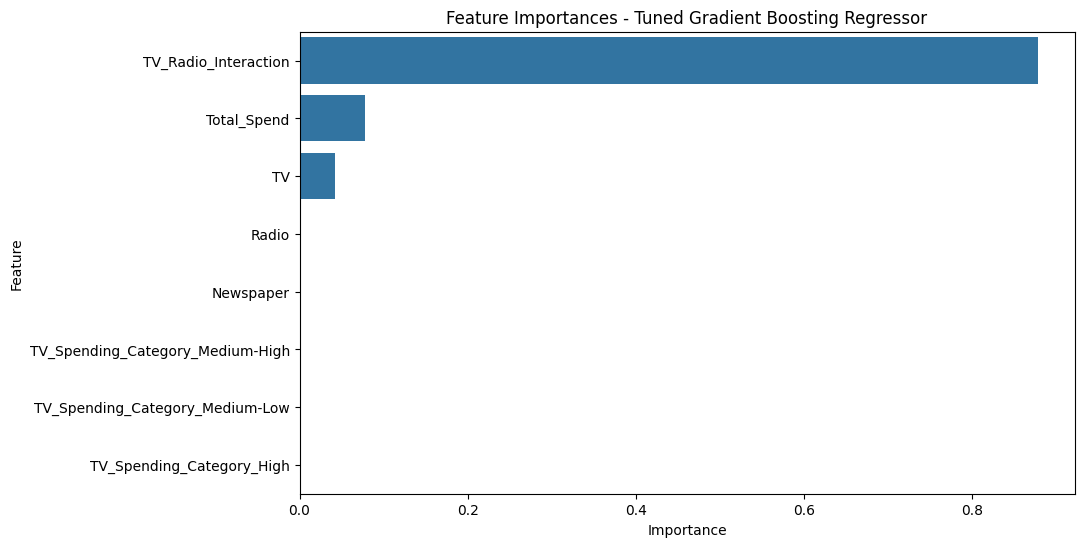

In [ ]:
importances = best_gb_model.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances from Tuned Gradient Boosting Regressor:")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances - Tuned Gradient Boosting Regressor')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Business Insights and Recommendations

Based on the comprehensive analysis of advertising data and the performance of various regression models, here are key business insights and actionable recommendations:

### 1. Optimal Model for Sales Prediction

*   The **Gradient Boosting Regressor (Tuned)** model emerged as the most accurate predictor of sales, achieving the lowest Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the highest R-squared value (0.9863). This indicates its superior ability to capture the underlying patterns in the data and generalize to unseen sales figures.
*   The **XGBoost Regressor (Tuned)** also performed exceptionally well, closely following Gradient Boosting, suggesting that tree-based ensemble methods are highly effective for this dataset.

### 2. Key Drivers of Sales

*   **TV Advertising and its Interaction with Radio (`TV_Radio_Interaction`) are the Most Critical Factors:** The feature importance analysis clearly shows that `TV_Radio_Interaction` (the product of TV and Radio spending) is overwhelmingly the most significant predictor of sales, accounting for approximately 87.8% of the importance. This highlights a strong synergistic effect between TV and Radio advertising.
*   **Total Advertising Spend (`Total_Spend`) is also Highly Important:** This aggregated feature accounts for about 7.8% of the importance, indicating that the overall investment across channels plays a substantial role.
*   **Individual TV Spending is Still Significant:** TV advertising alone (4.2% importance) remains a key driver, reinforcing its direct impact on sales.
*   **Radio and Newspaper have Lesser Individual Direct Impact:** While Radio and Newspaper spending contribute to the total spend and interact with TV, their individual direct importance as standalone features is relatively low (0.1% and 0.08% respectively). The categorical TV spending features (`TV_Spending_Category_Medium-High`, `TV_Spending_Category_Medium-Low`, `TV_Spending_Category_High`) show very minimal direct importance, indicating that the continuous spending amounts and their interactions are more influential.

### 3. Actionable Recommendations

*   **Prioritize Synergistic Campaigns between TV and Radio:** Given the extremely high importance of `TV_Radio_Interaction`, advertising strategies should focus on integrated campaigns where TV and Radio advertisements are coordinated to amplify each other's effects. Investing in both channels simultaneously is likely to yield disproportionately higher returns than investing in either alone.
*   **Maintain Strong Investment in TV Advertising:** TV remains a foundational advertising channel. While its individual importance is lower than the interaction term, it's a critical component of the most impactful interaction.
*   **Re-evaluate Newspaper Advertising Effectiveness:** Newspaper advertising shows the lowest individual impact. Businesses should consider optimizing or potentially reallocating budget from Newspaper to TV and Radio, especially for combined campaigns, unless there are specific target demographics uniquely reached by newspapers that justify the expenditure.
*   **Monitor Total Advertising Spend for Scalability:** Since `Total_Spend` is also important, businesses should aim to strategically increase overall advertising investment, ensuring that the additional spend is distributed effectively across high-impact channels and synergistic combinations.
*   **Utilize the Gradient Boosting Model for Future Sales Forecasting:** The tuned Gradient Boosting Regressor should be deployed for predicting future sales, providing reliable forecasts to guide business planning and inventory management. This model can also be used to simulate the impact of different advertising budget allocations.

By focusing on these insights, businesses can optimize their advertising expenditure, maximize sales, and achieve a higher return on investment.

## Marketing Strategy Recommendations

Based on the derived business insights, here are actionable marketing strategy recommendations to optimize advertising spend and maximize sales:

### 1. **Integrated TV and Radio Campaigns**

*   **Recommendation:** Develop and execute highly integrated campaigns where TV and Radio advertising work in tandem. The `TV_Radio_Interaction` feature's dominant importance indicates that the combined effect of these two channels far surpasses their individual contributions. This means a dollar spent simultaneously on both could yield significantly higher returns than spending it on only one.
*   **Actionable Steps:**
    *   **Consistent Messaging:** Ensure brand messaging, creative elements, and calls to action are consistent across TV and Radio advertisements.
    *   **Synchronized Schedules:** Plan TV and Radio ad placements to run concurrently, maximizing exposure and reinforcing the message across different media touchpoints.
    *   **Cross-Promotion:** Use TV ads to drive listeners to radio segments (e.g., for longer stories, interviews, or promotions) and vice-versa, creating a cohesive brand experience.

### 2. **Strategic Allocation of Advertising Budget**

*   **Recommendation:** Reallocate advertising budgets to favor TV and Radio, particularly for their synergistic combination, and reduce reliance on Newspaper advertising.
*   **Actionable Steps:**
    *   **Increase TV & Radio Budget:** Allocate a larger proportion of the marketing budget to TV and Radio, focusing on high-reach and high-engagement slots.
    *   **Optimize Newspaper Spend:** Review the effectiveness of current Newspaper campaigns. If the target audience for newspapers is not critical or not uniquely reachable, consider significantly reducing or re-purposing this budget towards TV and Radio. For specific niche audiences still reached by newspapers, explore highly targeted, cost-effective placements.
    *   **Data-Driven Budgeting:** Continuously monitor the performance of integrated campaigns and adjust budgets dynamically based on real-time sales data and model predictions.

### 3. **Focus on Total Advertising Impact**

*   **Recommendation:** While individual channel effectiveness is important, always consider the overall `Total_Spend` and how each additional dollar contributes to the combined effect across channels.
*   **Actionable Steps:**
    *   **Unified Campaign Planning:** Plan advertising campaigns not in isolation for each channel, but as a holistic entity where the sum of parts contributes to a greater sales outcome.
    *   **Experiment with Spend Levels:** Conduct controlled experiments (e.g., A/B testing in different markets if feasible) to understand the optimal total spend that maximizes sales without diminishing returns.

### 4. **Leverage Predictive Modeling for Forecasting and Optimization**

*   **Recommendation:** Utilize the Gradient Boosting Regressor model (or a similar high-performing model like XGBoost) for ongoing sales forecasting and strategic planning.
*   **Actionable Steps:**
    *   **Sales Forecasting:** Implement the trained model to predict sales based on planned advertising spend, providing more accurate revenue projections.
    *   **Scenario Planning:** Use the model to simulate the impact of different advertising budget allocations and strategies on predicted sales. For example, evaluate the potential sales increase from a 10% increase in TV and Radio spend versus a similar increase in Newspaper spend.
    *   **Continuous Improvement:** Regularly retrain the model with new data to ensure its accuracy and relevance as market conditions and advertising effectiveness evolve.

In [35]:
# Define the filename for saving the model
model_filename = 'best_gradient_boosting_model.pkl'

# Save the best Gradient Boosting Regressor model
joblib.dump(best_gb_model, model_filename)

print(f"Best Gradient Boosting Regressor model saved to {model_filename}")

Best Gradient Boosting Regressor model saved to best_gradient_boosting_model.pkl
